In [1]:
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings("ignore")

In [2]:
import torch

from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel,
)
from PycalcAct.trainer import Trainer

_ = torch.manual_seed(1234)


In [3]:
myPath = 'D:\\SebastienThis\\CalciumPredictions\\Ca2-Analysis_McGill\\dataExport\\dataMcGill\\'
HMRdata = 'D:\\SebastienThis\\CalciumPredictions\\CalciumTracking_v2\\dataExport\\HMR_OVA_APL\\'
dataset = Dataset(
    csv_path=myPath+"legend.csv",
    csv_pos_path=myPath+"position.csv",  # Optional
    position_to_displacement=True,
    # Convert the x, y position to a single displacement value (sqrt((x(t+1)-x(t))^2 + (y(t+1)-y(t))^2)
)
model = MixedFCTemporalModel(
    n_classes=dataset.n_classes,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
)

n_epochs = 750
trainer = Trainer(
    dataset, model, device="cuda"
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


In [4]:
trainer.summary(optimizer=False, model=True, data=True)

Model
Layer (type:depth-idx)                   Output Shape              Param #
MixedFCTemporalModel                     [10, 4]                   --
├─GRU: 1-1                               [10, 120, 64]             25,728
├─Sequential: 1-2                        [10, 64]                  --
│    └─Sequential: 2-1                   [10, 64]                  --
│    │    └─Linear: 3-1                  [10, 64]                  491,584
│    │    └─ReLU: 3-2                    [10, 64]                  --
│    │    └─Dropout1d: 3-3               [10, 64]                  --
│    └─Sequential: 2-2                   [10, 64]                  --
│    │    └─Linear: 3-4                  [10, 64]                  4,160
│    │    └─ReLU: 3-5                    [10, 64]                  --
│    │    └─Dropout1d: 3-6               [10, 64]                  --
├─Linear: 1-3                            [10, 4]                   260
Total params: 521,732
Trainable params: 521,732
Non-trainable para

,Total,N4,Q4,Q4H7,T4
Train,16084,6144,4790,2299,2851
Validation,4022,1536,1198,575,713
Test,5027,1920,1497,719,891
Total,25133,9600,7485,3593,4455


# Learning with Displacement encoding

╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.39 │                     38.19 │
│             3             │                      1.37 │                     41.40 │
│             4             │                      1.35 │                     43.44 │
│             5             │                      1.34 │                     45.08 │
│             11            │                      1.29 │                     46.27 │
│             12            │                      1.29 │                     46.97 │
│             13            │                      1.27 │                     47.59 │
│             15            │                      1.27 │                     47.81 │
│             19            │                      1.2

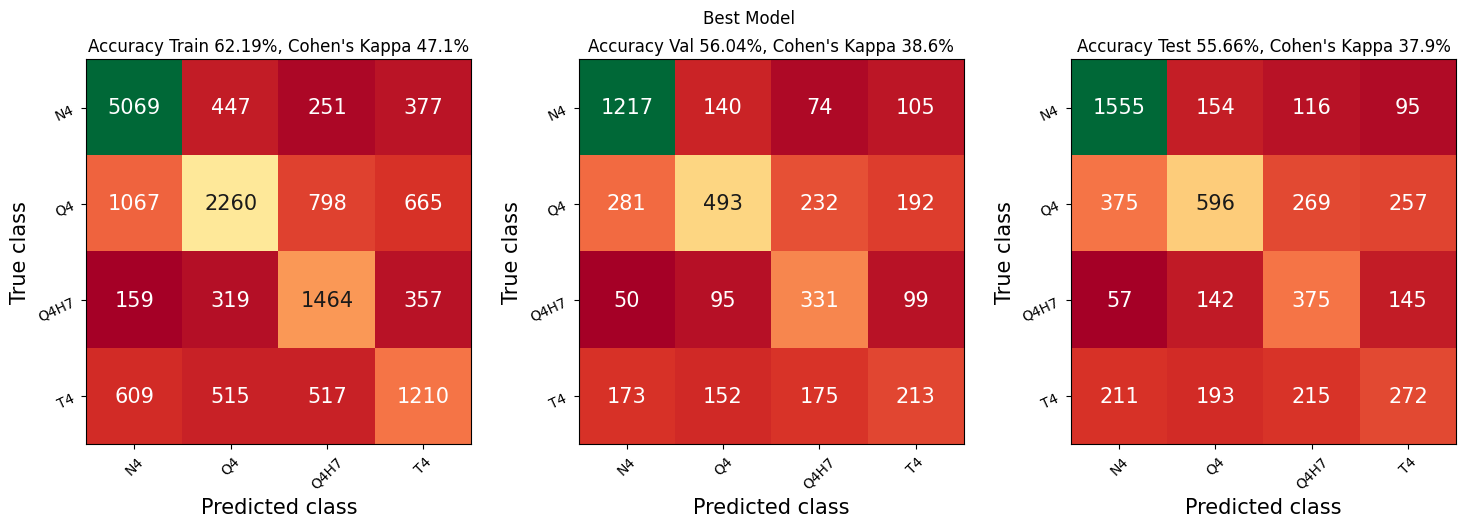

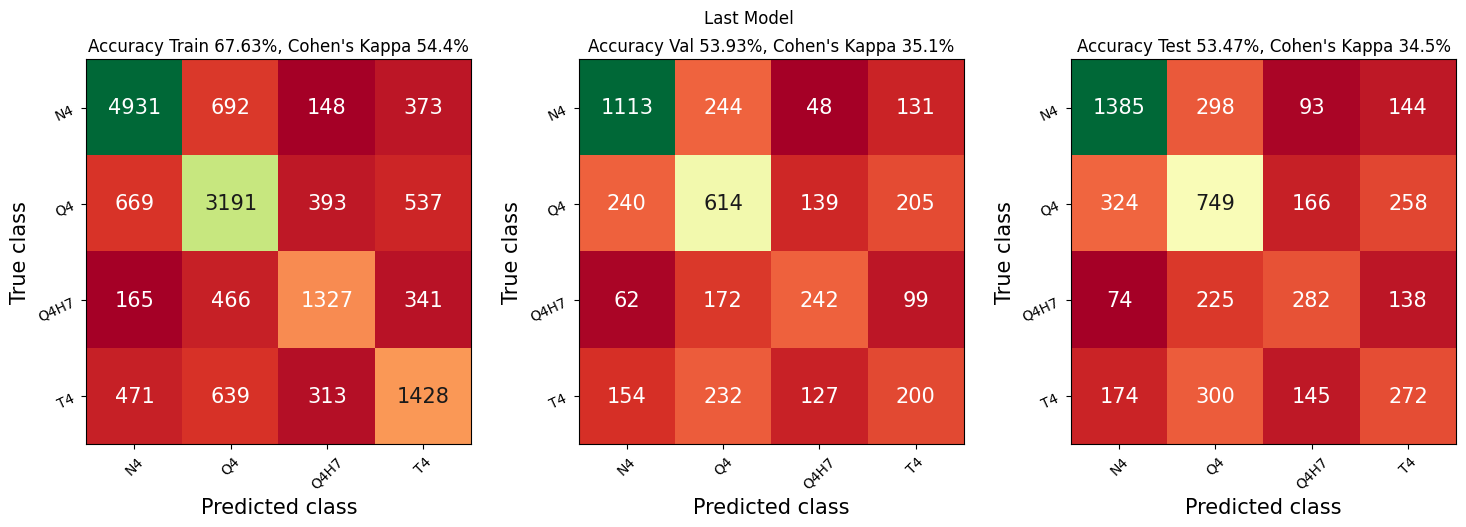

In [5]:
trainer.train(n_epochs)
trainer.test("best")  # Testing on the best model (in term of validation accuracy)
trainer.test("last")  # Testing on the last model

trainer.save()

In [6]:
datasetHMR = Dataset(
    csv_path=HMRdata+"legend.csv",
    csv_pos_path=HMRdata+"position.csv",  # Optional
    position_to_displacement=True,
    # Convert the x, y position to a single displacement value (sqrt((x(t+1)-x(t))^2 + (y(t+1)-y(t))^2)
)
datasetHMR.summarize()

Dataset summary: timepoints 120, features 2


,Total,N4,Q4,Q4H7,T4
Train,2466,965,642,106,753
Validation,617,242,160,26,189
Test,771,302,200,33,236
Total,3854,1509,1002,165,1178


In [9]:
trainerHMR = Trainer(
    datasetHMR, trainer.model, device="cuda"
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


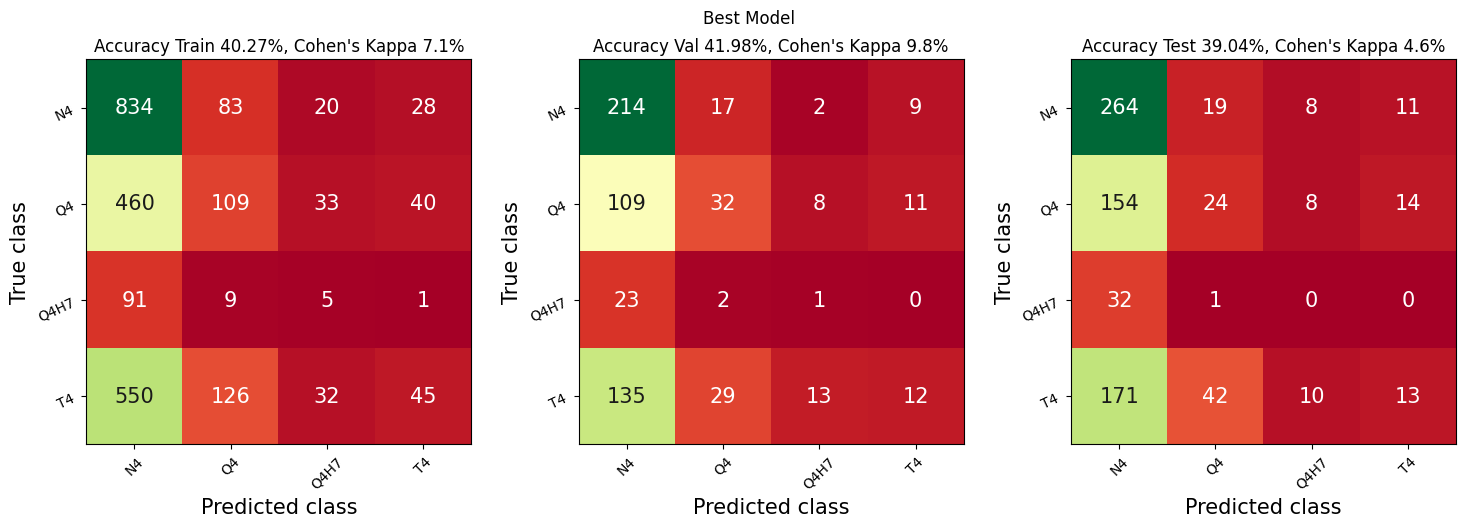

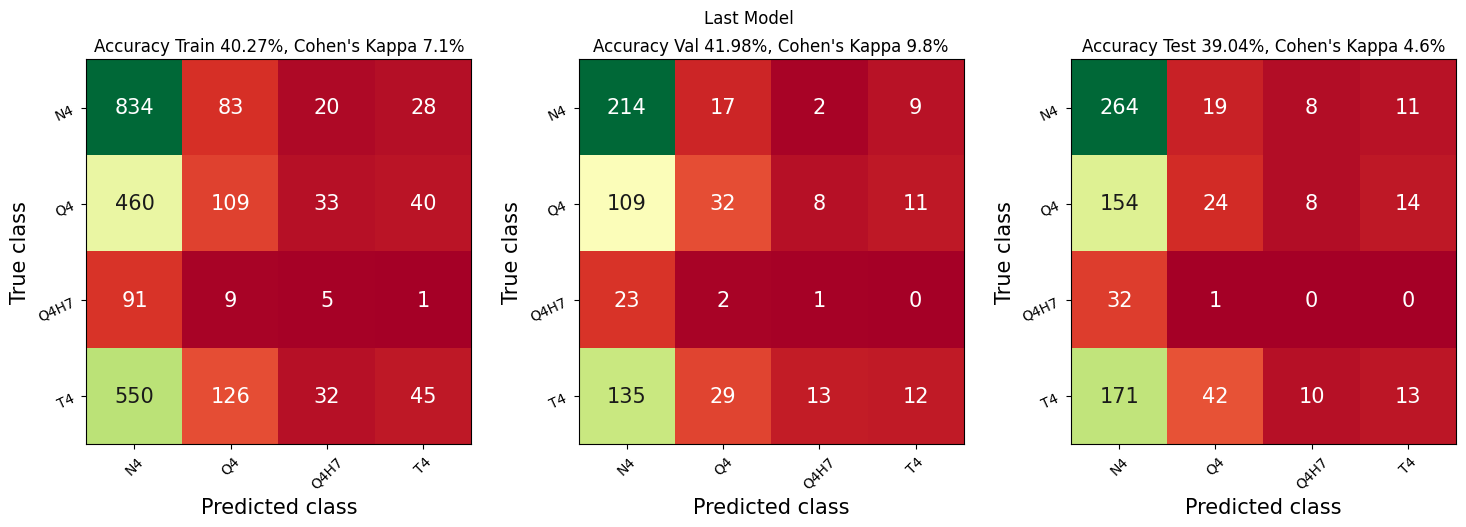

In [12]:
trainerHMR.test('best')
trainerHMR.test('last')